In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon

plt.style.use("seaborn-v0_8-whitegrid")

# Data

In [2]:
results_raw = pd.read_csv("results.csv").drop('Unnamed: 0', axis=1)
results_real = results_raw[results_raw["data_analysis"] == "real_only"]
results_syn = results_raw[~(results_raw["data_analysis"] == "real_only")]
results = results_syn.merge(results_real[["symbol", "model_name", "test_mse", "test_mape"]],
                            how='left',
                            on=["symbol", "model_name"])
results

,symbol,data,data_weights,model_name,val_mse,test_mse_x,test_mae,test_mape_x,test_mse_y,test_mape_y
0,BTC,SB,1.0,LSTM,0.001488,0.001143,0.023490,3.235496,0.001157,3.269740
1,BTC,SB,1.0,BD_LSTM,0.001482,0.001130,0.023308,3.200293,0.001135,3.216385
2,BTC,SB,1.0,TCN,0.001480,0.001133,0.023326,3.207864,0.005646,8.219616
3,BTC,SB,10.0,LSTM,0.001495,0.001142,0.023523,3.227993,0.001157,3.269740
4,BTC,SB,10.0,BD_LSTM,0.001495,0.001142,0.023542,3.234440,0.001135,3.216385
...,...,...,...,...,...,...,...,...,...,...
76,XRP,TCVAE,10.0,BD_LSTM,0.002041,0.001164,0.024022,4.921871,0.001181,4.974643
77,XRP,TCVAE,10.0,TCN,0.002053,0.001137,0.023308,4.739130,0.002047,6.737036
78,XRP,TCVAE,50.0,LSTM,0.002066,0.001155,0.023645,4.817891,0.001185,4.967925
79,XRP,TCVAE,50.0,BD_LSTM,0.002080,0.001163,0.023710,4.817361,0.001181,4.974643


# Synthetic data improvement

## Overall

In [3]:
results["syn_improved"] = np.where(results["test_mse_x"] < results["test_mse_y"], 1, 0)
results.groupby("data_analysis")["syn_improved"].mean()

data
QGAN     0.555556
SB       0.629630
TCVAE    1.000000
Name: syn_improved, dtype: float64

In [4]:
results["mape_improve"] = results["test_mape_x"] - results["test_mape_y"]
results.groupby("data_analysis")["mape_improve"].mean()

data
QGAN    -1.280865
SB      -1.312328
TCVAE   -1.379478
Name: mape_improve, dtype: float64

## Per cryptocurrency, synthethic generation method

In [5]:
results.groupby(["symbol", "data_analysis"])[["syn_improved", "mape_improve"]].mean()


syn_improved  mape_improve
symbol data                             
BTC    QGAN       0.666667     -1.651068
       SB         0.666667     -1.666758
       TCVAE      1.000000     -1.686216
ETH    QGAN       0.666667     -1.694508
       SB         0.666667     -1.695237
       TCVAE      1.000000     -1.720860
XRP    QGAN       0.333333     -0.497019
       SB         0.555556     -0.574988
       TCVAE      1.000000     -0.731358

## Per pred model, synthethic generation method

In [6]:
results.groupby(["model_name", "data_analysis"])[["syn_improved", "mape_improve"]].mean()

syn_improved  mape_improve
model_name data                             
BD_LSTM    QGAN       0.333333      0.018721
           SB         0.333333      0.020313
           TCVAE      1.000000     -0.052642
LSTM       QGAN       0.333333      0.074331
           SB         0.555556      0.035182
           TCVAE      1.000000     -0.071403
TCN        QGAN       1.000000     -3.935647
           SB         1.000000     -3.992478
           TCVAE      1.000000     -4.014390

# Boxplot per synthetic model

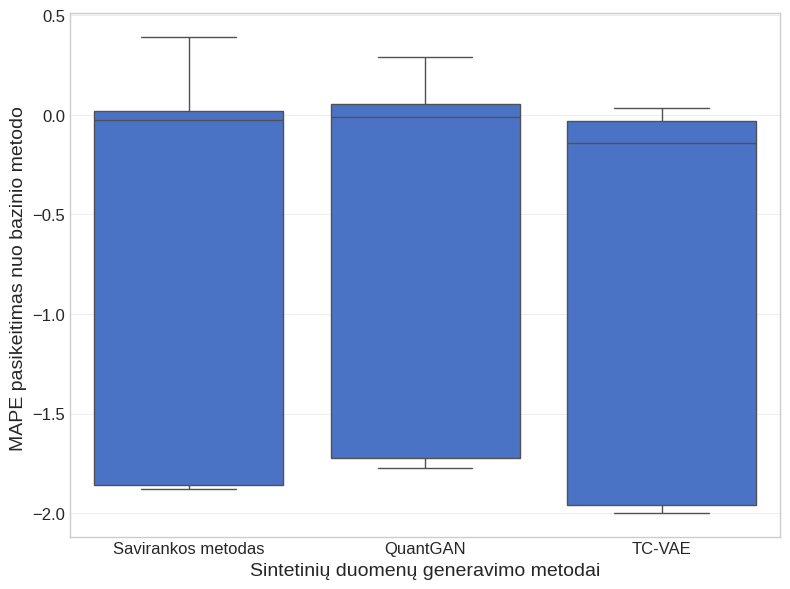

In [7]:
results_b = results.copy()
results_b["data_analysis"] = results_b["data_analysis"].replace({
    "SB": "Savirankos metodas",
    "QGAN": "QuantGAN",
    "TCVAE": "TC-VAE"
})

order = ["Savirankos metodas", "QuantGAN", "TC-VAE"]
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(results_b,
            x="data_analysis",
            y="mape_improve",
            ax=ax,
            order=order,
            showfliers=False)

ax.set_xlabel("Sintetinių duomenų generavimo metodai", fontsize=14)
ax.set_ylabel("MAPE pasikeitimas nuo bazinio metodo ", fontsize=14)

ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)

plt.tight_layout()


# Heatmap data x model, crypto

In [8]:
results_h = results_raw.copy()
results_h["model_name"] = results_h["model_name"].replace({
    "BD_LSTM": "BD-LSTM"
})

results_h["data_analysis"] = results_h["data_analysis"].replace({
    "real_only": "Tik realūs",
    "SB": "Savirankos metodas",
    "QGAN": "QuantGAN",
    "TCVAE": "TC-VAE"
})

results_h["data_weights"] = results_h["data_weights"].astype('Int64')

results_h["crypto_model"] = results_h["model_name"] + ", " + results_h["symbol"]
results_h["data_model"] = (
    results_h["data_analysis"] + ", " + results_h["data_weights"].astype(str).fillna("")
)
results_h

,symbol,data,data_weights,model_name,val_mse,test_mse,test_mae,test_mape,crypto_model,data_model
0,BTC,Tik realūs,<NA>,LSTM,0.001495,0.001140,0.023474,3.217809,"LSTM, BTC","Tik realūs,"
1,BTC,Tik realūs,<NA>,BD-LSTM,0.001486,0.001139,0.023435,3.223540,"BD-LSTM, BTC","Tik realūs,"
2,BTC,Tik realūs,<NA>,TCN,0.005709,0.005128,0.060011,8.029217,"TCN, BTC","Tik realūs,"
3,ETH,Tik realūs,<NA>,LSTM,0.001889,0.002188,0.032648,4.541128,"LSTM, ETH","Tik realūs,"
4,ETH,Tik realūs,<NA>,BD-LSTM,0.001882,0.002159,0.032272,4.513619,"BD-LSTM, ETH","Tik realūs,"
...,...,...,...,...,...,...,...,...,...,...
85,XRP,TC-VAE,10,BD-LSTM,0.002060,0.001163,0.023890,4.884594,"BD-LSTM, XRP","TC-VAE, 10"
86,XRP,TC-VAE,10,TCN,0.002054,0.001148,0.023710,4.841229,"TCN, XRP","TC-VAE, 10"
87,XRP,TC-VAE,50,LSTM,0.002127,0.001212,0.024531,4.989443,"LSTM, XRP","TC-VAE, 50"
88,XRP,TC-VAE,50,BD-LSTM,0.002064,0.001182,0.024293,4.979870,"BD-LSTM, XRP","TC-VAE, 50"


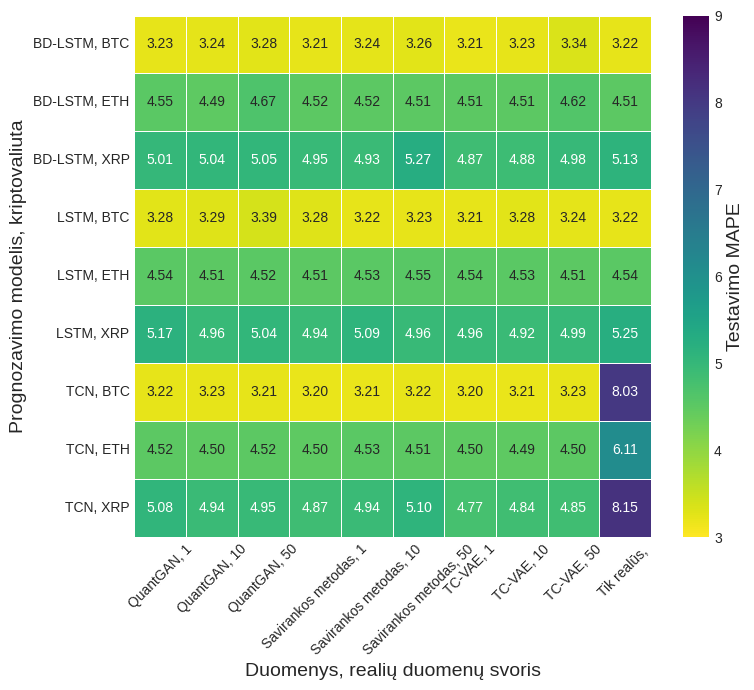

In [9]:
heatmap_df = results_h.pivot_table(
    index="crypto_model",
    columns="data_model",
    values="test_mape"
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap="viridis_r",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    vmin=3,
    vmax=9,
    cbar_kws={"label": "Testavimo MAPE"}
)
cbar = ax.figure.axes[-1]
cbar.yaxis.label.set_size(14)

ax.set_xlabel("Duomenys, realių duomenų svoris", fontsize=14)
ax.set_ylabel("Prognozavimo modelis, kriptovaliuta", fontsize=14)

plt.yticks(rotation=0, fontsize=10)
plt.xticks(rotation=45, fontsize=10)

plt.tight_layout()

# Best configuration for each cryptocurrency

In [10]:
results_raw[results_raw["symbol"] == "BTC"].sort_values(by="test_mape", ascending=True)

,symbol,data,data_weights,model_name,val_mse,test_mse,test_mae,test_mape
65,BTC,TCVAE,1.0,TCN,0.001456,0.001107,0.023075,3.198877
11,BTC,SB,1.0,TCN,0.001480,0.001129,0.023302,3.199195
64,BTC,TCVAE,1.0,BD_LSTM,0.001460,0.001112,0.023145,3.205937
68,BTC,TCVAE,10.0,TCN,0.001455,0.001113,0.023122,3.206554
14,BTC,SB,10.0,TCN,0.001482,0.001133,0.023330,3.209066
44,BTC,QGAN,50.0,TCN,0.001483,0.001135,0.023359,3.212429
10,BTC,SB,1.0,BD_LSTM,0.001487,0.001136,0.023394,3.214964
63,BTC,TCVAE,1.0,LSTM,0.001458,0.001115,0.023162,3.214969
17,BTC,SB,50.0,TCN,0.001484,0.001136,0.023383,3.217789
0,BTC,real_only,NaN,LSTM,0.001495,0.001140,0.023474,3.217809


In [11]:
results_raw[results_raw["symbol"] == "ETH"].sort_values(by="test_mape", ascending=True)

,symbol,data,data_weights,model_name,val_mse,test_mse,test_mae,test_mape
77,ETH,TCVAE,10.0,TCN,0.001852,0.002132,0.031980,4.489768
49,ETH,QGAN,10.0,BD_LSTM,0.001876,0.002149,0.032095,4.491354
50,ETH,QGAN,10.0,TCN,0.001875,0.002151,0.032149,4.496335
20,ETH,SB,1.0,TCN,0.001868,0.002153,0.032174,4.498913
74,ETH,TCVAE,1.0,TCN,0.001846,0.002140,0.032072,4.499980
80,ETH,TCVAE,50.0,TCN,0.001847,0.002142,0.032115,4.501153
73,ETH,TCVAE,1.0,BD_LSTM,0.001852,0.002138,0.032106,4.506164
26,ETH,SB,50.0,TCN,0.001880,0.002152,0.032170,4.506614
76,ETH,TCVAE,10.0,BD_LSTM,0.001863,0.002132,0.032043,4.508941
78,ETH,TCVAE,50.0,LSTM,0.001862,0.002132,0.032050,4.510043


In [12]:
results_raw[results_raw["symbol"] == "XRP"].sort_values(by="test_mape", ascending=True)

,symbol,data,data_weights,model_name,val_mse,test_mse,test_mae,test_mape
83,XRP,TCVAE,1.0,TCN,0.002052,0.001138,0.023431,4.767677
86,XRP,TCVAE,10.0,TCN,0.002054,0.001148,0.023710,4.841229
89,XRP,TCVAE,50.0,TCN,0.002052,0.001159,0.023762,4.851140
29,XRP,SB,1.0,TCN,0.002089,0.001164,0.023655,4.869184
82,XRP,TCVAE,1.0,BD_LSTM,0.002052,0.001155,0.023826,4.872151
85,XRP,TCVAE,10.0,BD_LSTM,0.002060,0.001163,0.023890,4.884594
84,XRP,TCVAE,10.0,LSTM,0.002066,0.001172,0.024074,4.923961
31,XRP,SB,10.0,BD_LSTM,0.002096,0.001173,0.023906,4.932487
32,XRP,SB,10.0,TCN,0.002086,0.001169,0.023915,4.936241
59,XRP,QGAN,10.0,TCN,0.002090,0.001175,0.023911,4.936722


## Statistical testing

In [32]:
for symbol in results["symbol"].unique():
    for pred_model in results["model_name"].unique():
        base_name = f"{symbol}_{pred_model}_real_only.csv"
        base_df = pd.read_csv(f"../data/predictions/{base_name}")
        base_df["mse"] = (base_df["real"] - base_df["pred"]) ** 2
        base_error = base_df["mse"].values

        for data in results["data_analysis"].unique():
            syn_name = f"{symbol}_{pred_model}_{data}_w1.csv"
            syn_df = pd.read_csv(f"../data/predictions/{syn_name}")
            syn_df["mse"] = (syn_df["real"] - syn_df["pred"]) ** 2
            syn_error = syn_df["mse"].values

            stat, p_value = wilcoxon(base_error, syn_error, alternative='greater')

            print(symbol, pred_model, data, p_value)

BTC LSTM SB 0.07378726634075684
BTC LSTM QGAN 0.004789872456142863
BTC LSTM TCVAE 0.000537656641229714
BTC BD_LSTM SB 0.036913002588458914
BTC BD_LSTM QGAN 0.4876751201823702
BTC BD_LSTM TCVAE 0.012392666201114238
BTC TCN SB 3.4088512531545723e-181
BTC TCN QGAN 2.9118997708391005e-181
BTC TCN TCVAE 1.1336361871953388e-181
ETH LSTM SB 0.7099137751779079
ETH LSTM QGAN 0.9844422674822569
ETH LSTM TCVAE 0.17408434891690006
ETH BD_LSTM SB 0.1504091997006335
ETH BD_LSTM QGAN 0.12689128573150554
ETH BD_LSTM TCVAE 0.016122342437144648
ETH TCN SB 3.393279578043021e-145
ETH TCN QGAN 5.974117455693458e-143
ETH TCN TCVAE 4.863559544638626e-139
XRP LSTM SB 0.7926150968950764
XRP LSTM QGAN 0.9999977691153233
XRP LSTM TCVAE 2.9267095608784255e-06
XRP BD_LSTM SB 0.5614815461137012
XRP BD_LSTM QGAN 0.9993055442722355
XRP BD_LSTM TCVAE 0.009401792592172668
XRP TCN SB 3.824286113685399e-61
XRP TCN QGAN 1.3635785945500078e-46
XRP TCN TCVAE 1.2848729249420435e-59


# Weight analysis

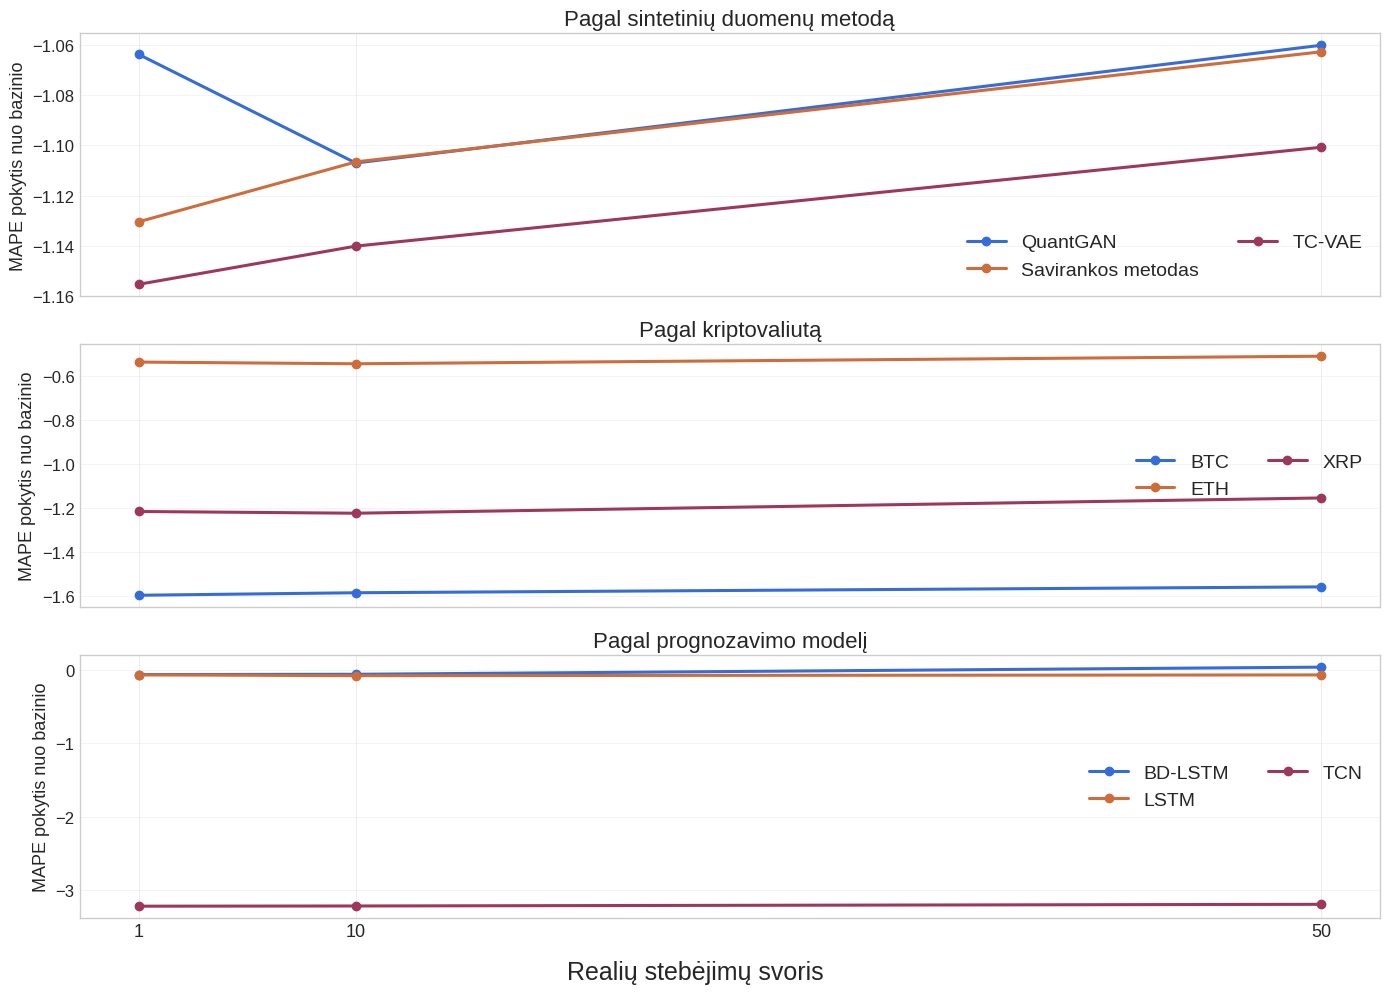

In [13]:
result_w = results_b.copy()
result_w["model_name"] = result_w["model_name"].replace({
    "BD_LSTM": "BD-LSTM"
})

data_weights = result_w.groupby(['data_analysis', 'data_weights'])["mape_improve"].mean().reset_index()
symbol_weights = result_w.groupby(['symbol', 'data_weights'])["mape_improve"].mean().reset_index()
model_weights = result_w.groupby(['model_name', 'data_weights'])["mape_improve"].mean().reset_index()

lw = 2.2
marker = "o"

xticks = sorted(result_w["data_weights"].unique())

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)

for data in data_weights['data_analysis'].unique():
    single = data_weights[data_weights['data_analysis'] == data]
    ax[0].plot(single["data_weights"],
               single["mape_improve"],
               label=data,
               linewidth=lw,
               marker=marker)

for symbol in symbol_weights['symbol'].unique():
    single = symbol_weights[symbol_weights['symbol'] == symbol]
    ax[1].plot(single["data_weights"],
               single["mape_improve"],
               label=symbol,
               linewidth=lw,
               marker=marker)

for model in model_weights['model_name'].unique():
    single = model_weights[model_weights['model_name'] == model]
    ax[2].plot(single["data_weights"],
               single["mape_improve"],
               label=model,
               linewidth=lw,
               marker=marker)

titles = ["Pagal sintetinių duomenų metodą", "Pagal kriptovaliutą", "Pagal prognozavimo modelį"]

for i, a in enumerate(ax):
    a.set_title(titles[i], fontsize=16)
    a.set_ylabel("MAPE pokytis nuo bazinio", fontsize=13)
    a.grid(axis="y", alpha=0.3)
    a.tick_params(axis="y", labelsize=12)

    a.set_xticks(xticks)
    a.tick_params(axis="x", labelsize=13)

fig.supxlabel("Realių stebėjimų svoris", fontsize=18)


ax[0].legend(fontsize=14, ncol=2, loc="lower right")
ax[1].legend(fontsize=14, ncol=2, loc="center right")
ax[2].legend(fontsize=14, ncol=2, loc="center right")


plt.tight_layout()


## Statistical significance

In [23]:
w10

,symbol,data,data_weights,model_name,val_mse,test_mse_x,test_mae,test_mape_x,test_mse_y,test_mape_y,syn_improved,mape_improve
3,BTC,SB,10.0,LSTM,0.001492,0.001139,0.023473,3.220675,0.001140,3.217809,1,0.002865
4,BTC,SB,10.0,BD_LSTM,0.001493,0.001146,0.023579,3.240359,0.001139,3.223540,0,0.016819
5,BTC,SB,10.0,TCN,0.001482,0.001133,0.023330,3.209066,0.005128,8.029217,1,-4.820150
12,ETH,SB,10.0,LSTM,0.001897,0.002153,0.032219,4.526121,0.002188,4.541128,1,-0.015007
13,ETH,SB,10.0,BD_LSTM,0.001886,0.002156,0.032235,4.515076,0.002159,4.513619,1,0.001457
14,ETH,SB,10.0,TCN,0.001862,0.002182,0.032592,4.530214,0.003513,6.114533,1,-1.584319
21,XRP,SB,10.0,LSTM,0.002117,0.001213,0.024631,5.093431,0.001235,5.248594,1,-0.155162
22,XRP,SB,10.0,BD_LSTM,0.002096,0.001173,0.023906,4.932487,0.001209,5.128780,1,-0.196292
23,XRP,SB,10.0,TCN,0.002086,0.001169,0.023915,4.936241,0.002777,8.145437,1,-3.209196


In [24]:
for syn in results["data_analysis"].unique():
    syn_filter = results[results["data_analysis"] == syn]
    w1 = syn_filter[results["data_weights"] == 1]["test_mape_x"].values
    w10 = syn_filter[results["data_weights"] == 10]["test_mape_x"].values
    w50 = syn_filter[results["data_weights"] == 50]["test_mape_x"].values
    stat, p = friedmanchisquare(w1, w10, w50)
    print(syn, stat, p)

SB 3.555555555555543 0.16901331540606715
QGAN 3.555555555555543 0.16901331540606715
TCVAE 6.888888888888886 0.031922491834895754


/tmp/ipykernel_20641/1295512503.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w1 = syn_filter[results["data_weights"] == 1]["test_mape_x"].values
/tmp/ipykernel_20641/1295512503.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w10 = syn_filter[results["data_weights"] == 10]["test_mape_x"].values
/tmp/ipykernel_20641/1295512503.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w50 = syn_filter[results["data_weights"] == 50]["test_mape_x"].values
/tmp/ipykernel_20641/1295512503.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w1 = syn_filter[results["data_weights"] == 1]["test_mape_x"].values
/tmp/ipykernel_20641/1295512503.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  w10 = syn_filter[results["data_weights"] == 10]["test_mape_x"].values
/tmp/ipykernel_20641/1295512503.py:5: UserWarning: Boolean Series key will

In [15]:
|results
# stat, p = friedmanchisquare(before, during, after)

,symbol,data,data_weights,model_name,val_mse,test_mse_x,test_mae,test_mape_x,test_mse_y,test_mape_y,syn_improved,mape_improve
0,BTC,SB,1.0,LSTM,0.001509,0.001163,0.023851,3.282292,0.001140,3.217809,0,0.064483
1,BTC,SB,1.0,BD_LSTM,0.001487,0.001136,0.023394,3.214964,0.001139,3.223540,1,-0.008576
2,BTC,SB,1.0,TCN,0.001480,0.001129,0.023302,3.199195,0.005128,8.029217,1,-4.830022
3,BTC,SB,10.0,LSTM,0.001492,0.001139,0.023473,3.220675,0.001140,3.217809,1,0.002865
4,BTC,SB,10.0,BD_LSTM,0.001493,0.001146,0.023579,3.240359,0.001139,3.223540,0,0.016819
...,...,...,...,...,...,...,...,...,...,...,...,...
76,XRP,TCVAE,10.0,BD_LSTM,0.002060,0.001163,0.023890,4.884594,0.001209,5.128780,1,-0.244185
77,XRP,TCVAE,10.0,TCN,0.002054,0.001148,0.023710,4.841229,0.002777,8.145437,1,-3.304208
78,XRP,TCVAE,50.0,LSTM,0.002127,0.001212,0.024531,4.989443,0.001235,5.248594,1,-0.259151
79,XRP,TCVAE,50.0,BD_LSTM,0.002064,0.001182,0.024293,4.979870,0.001209,5.128780,1,-0.148910


In [16]:
results

,symbol,data,data_weights,model_name,val_mse,test_mse_x,test_mae,test_mape_x,test_mse_y,test_mape_y,syn_improved,mape_improve
0,BTC,SB,1.0,LSTM,0.001509,0.001163,0.023851,3.282292,0.001140,3.217809,0,0.064483
1,BTC,SB,1.0,BD_LSTM,0.001487,0.001136,0.023394,3.214964,0.001139,3.223540,1,-0.008576
2,BTC,SB,1.0,TCN,0.001480,0.001129,0.023302,3.199195,0.005128,8.029217,1,-4.830022
3,BTC,SB,10.0,LSTM,0.001492,0.001139,0.023473,3.220675,0.001140,3.217809,1,0.002865
4,BTC,SB,10.0,BD_LSTM,0.001493,0.001146,0.023579,3.240359,0.001139,3.223540,0,0.016819
...,...,...,...,...,...,...,...,...,...,...,...,...
76,XRP,TCVAE,10.0,BD_LSTM,0.002060,0.001163,0.023890,4.884594,0.001209,5.128780,1,-0.244185
77,XRP,TCVAE,10.0,TCN,0.002054,0.001148,0.023710,4.841229,0.002777,8.145437,1,-3.304208
78,XRP,TCVAE,50.0,LSTM,0.002127,0.001212,0.024531,4.989443,0.001235,5.248594,1,-0.259151
79,XRP,TCVAE,50.0,BD_LSTM,0.002064,0.001182,0.024293,4.979870,0.001209,5.128780,1,-0.148910
